In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1.	Data Cleaning and Preparation:

##### Load the dataset into a DataFrame or equivalent data structure.

In [9]:
data = pd.read_csv('Cardiotocographic.csv')
data.head() # it shows the first five rows

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [6]:
data.shape

(2126, 14)

In [8]:
data.tail() # it shows the last five rows

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
2121,140.0,0.000000,0.961268,0.007426,0.0,0.0,0.0,79.0,0.2,25.000000,7.2,40.0,0.0,2.000000
2122,140.0,0.000775,0.000000,0.006979,0.0,0.0,0.0,78.0,0.4,22.000000,7.1,66.0,1.0,2.000000
2123,140.0,0.000980,0.000000,0.006863,0.0,0.0,0.0,79.0,0.4,20.000000,6.1,67.0,1.0,1.990464
2124,140.0,0.000679,0.000000,0.006110,0.0,0.0,0.0,78.0,0.4,27.000000,7.0,66.0,1.0,2.000000
2125,142.0,0.001616,-0.000188,0.008078,0.0,0.0,0.0,74.0,0.4,35.857183,5.0,42.0,0.0,1.000000


In [13]:
data.columns

Index(['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV',
       'MLTV', 'Width', 'Tendency', 'NSP'],
      dtype='object')

In [16]:
data.info() #This method prints information about a DataFrame including the index dtype and columns, non-null values and memory usage.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


##### Handle missing values appropriately

In [17]:
data.isna().sum()

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

### 2. Statistical Summary

In [18]:
data.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2105.000000,2106.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2105.000000,2105.000000
mean,133.343598,0.003219,0.009894,0.004391,0.001895,0.000003,0.000175,46.995984,1.364378,10.285964,8.284887,70.429260,0.316371,1.304507
std,11.270154,0.004391,0.067540,0.003340,0.003343,0.000142,0.000840,18.813973,1.173632,21.205041,7.772858,42.931822,0.645622,0.644619
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.000000
75%,140.000000,0.005650,0.002567,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.900000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000


In [19]:
# Calculate interquartile range
interquartile_range = pd.DataFrame({
    'IQR': data.quantile(0.75) - data.quantile(0.25)
})

print(interquartile_range)

                IQR
LB        14.000000
AC         0.005650
FM         0.002567
UC         0.004685
DL         0.003289
DS         0.000000
DP         0.000000
ASTV      29.000000
MSTV       1.000000
ALTV      11.000000
MLTV       6.300000
Width     63.000000
Tendency   1.000000
NSP        0.000000


In [22]:
data.corr(numeric_only=True)

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
LB,1.000000,-0.063830,0.018777,-0.166570,-0.126959,-0.005438,-0.047724,0.242625,-0.170473,0.210728,-0.003457,-0.118425,0.236864,0.131843
AC,-0.063830,1.000000,0.009433,0.072012,-0.093507,-0.033623,-0.084590,-0.231103,0.134168,-0.271390,-0.106529,0.238436,0.032481,-0.316941
FM,0.018777,0.009433,1.000000,-0.053226,0.009718,0.029901,0.121284,-0.032691,0.017055,-0.011936,-0.006237,0.097213,-0.018339,0.074054
UC,-0.166570,0.072012,-0.053226,1.000000,0.190128,-0.006937,0.070658,-0.181161,0.189406,-0.227304,-0.049460,0.107397,-0.066610,-0.185411
DL,-0.126959,-0.093507,0.009718,0.190128,1.000000,0.058625,0.145425,-0.069361,0.410102,-0.186967,-0.165750,0.410031,-0.023569,0.025427
DS,-0.005438,-0.033623,0.029901,-0.006937,0.058625,1.000000,0.004285,0.008452,0.016163,-0.004398,0.034349,0.040832,-0.015398,0.065400
DP,-0.047724,-0.084590,0.121284,0.070658,0.145425,0.004285,1.000000,0.038238,0.119892,-0.077758,-0.114084,0.175340,-0.130395,0.294472
ASTV,0.242625,-0.231103,-0.032691,-0.181161,-0.069361,0.008452,0.038238,1.000000,-0.293882,0.357497,-0.220427,-0.207599,-0.010927,0.422652
MSTV,-0.170473,0.134168,0.017055,0.189406,0.410102,0.016163,0.119892,-0.293882,1.000000,-0.291935,0.028934,0.435393,-0.036857,-0.095139
ALTV,0.210728,-0.271390,-0.011936,-0.227304,-0.186967,-0.004398,-0.077758,0.357497,-0.291935,1.000000,-0.107712,-0.346460,0.036771,0.365846


### 3.	Data Visualization:

##### Create histograms or boxplots to visualize the distributions of various numerical variables.

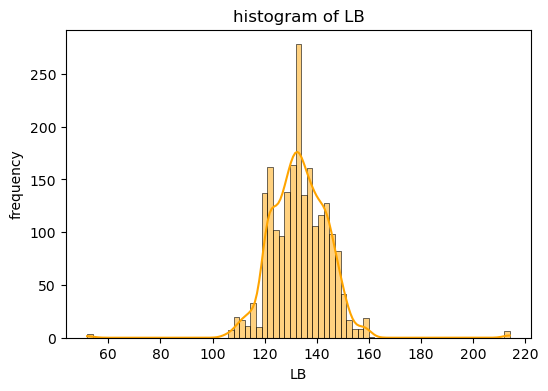

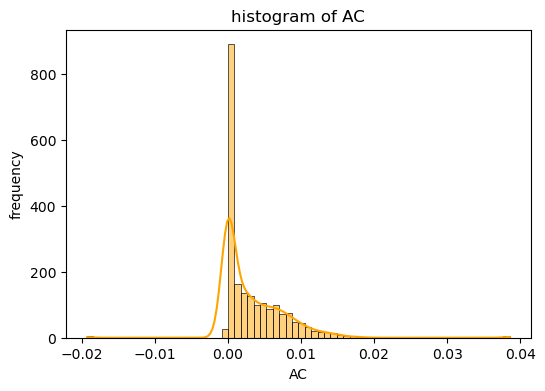

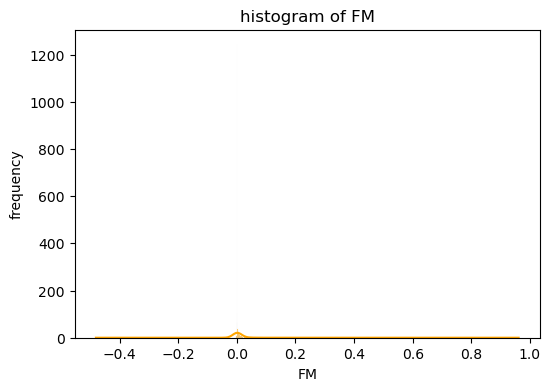

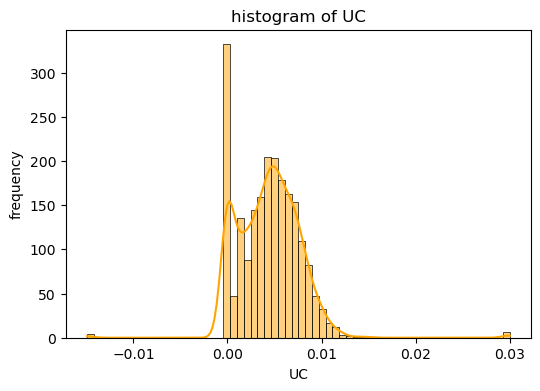

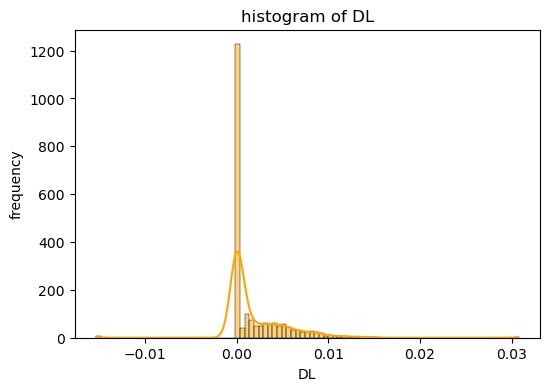

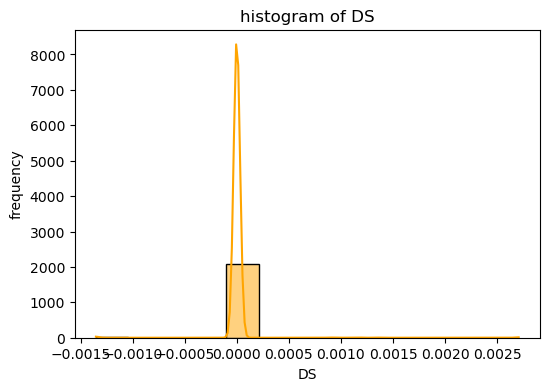

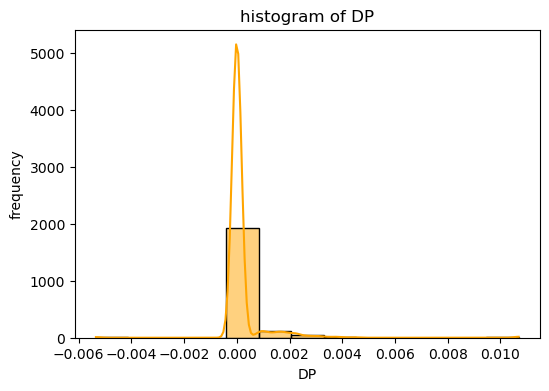

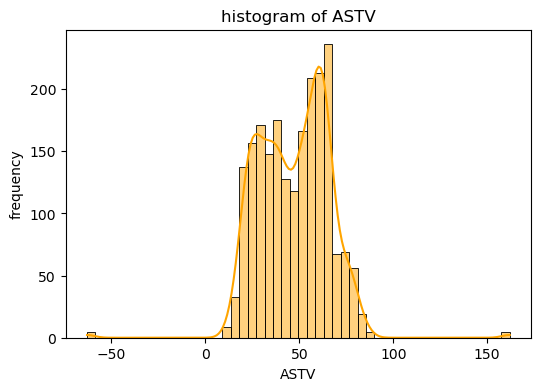

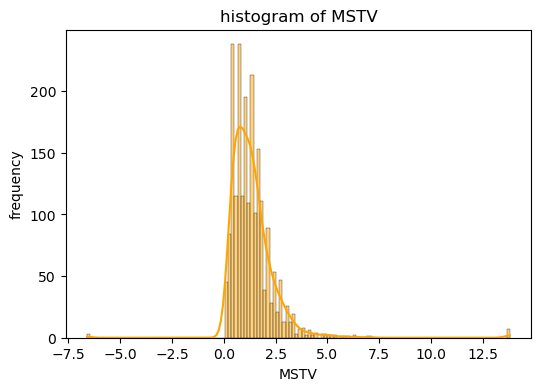

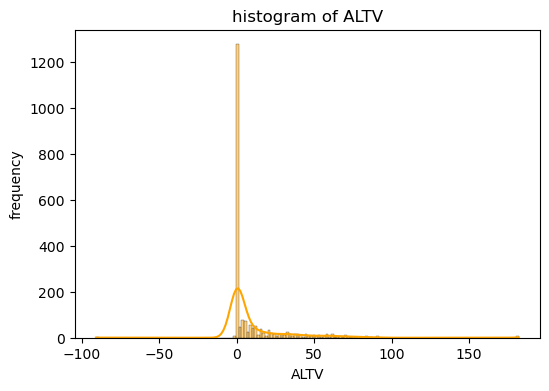

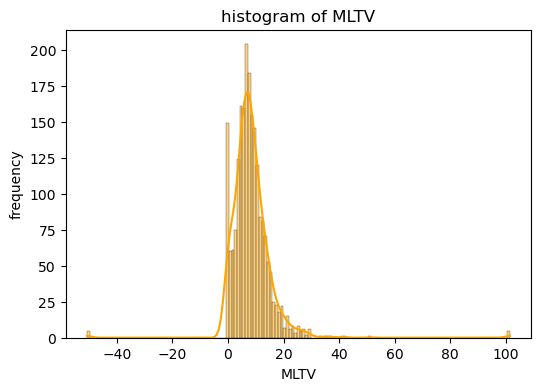

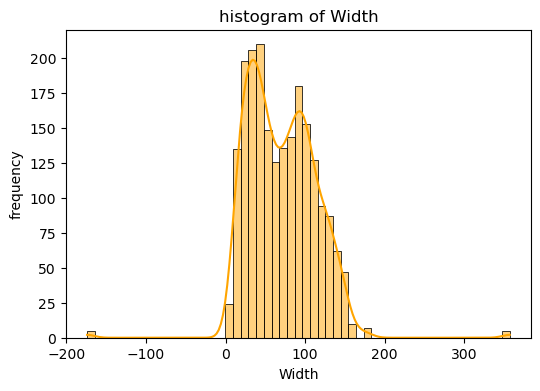

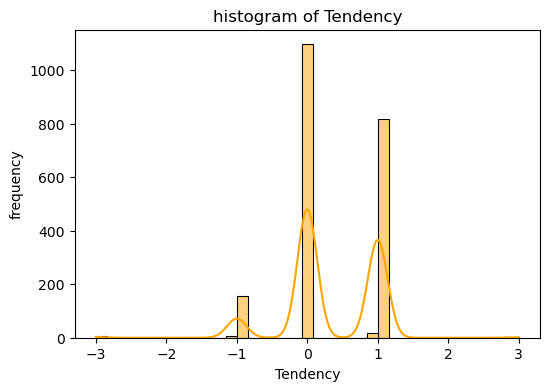

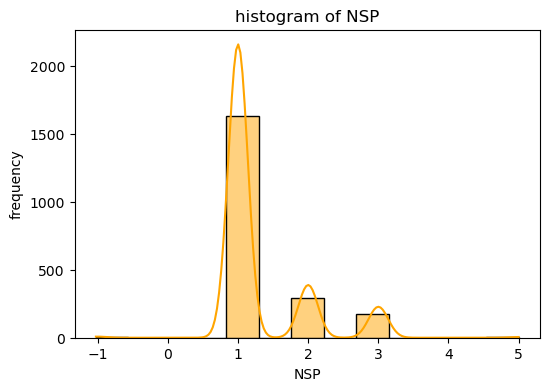

In [23]:
for col in data.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col],kde=True,color='orange',edgecolor='black')
    plt.title(f'histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('frequency')
    plt.show()

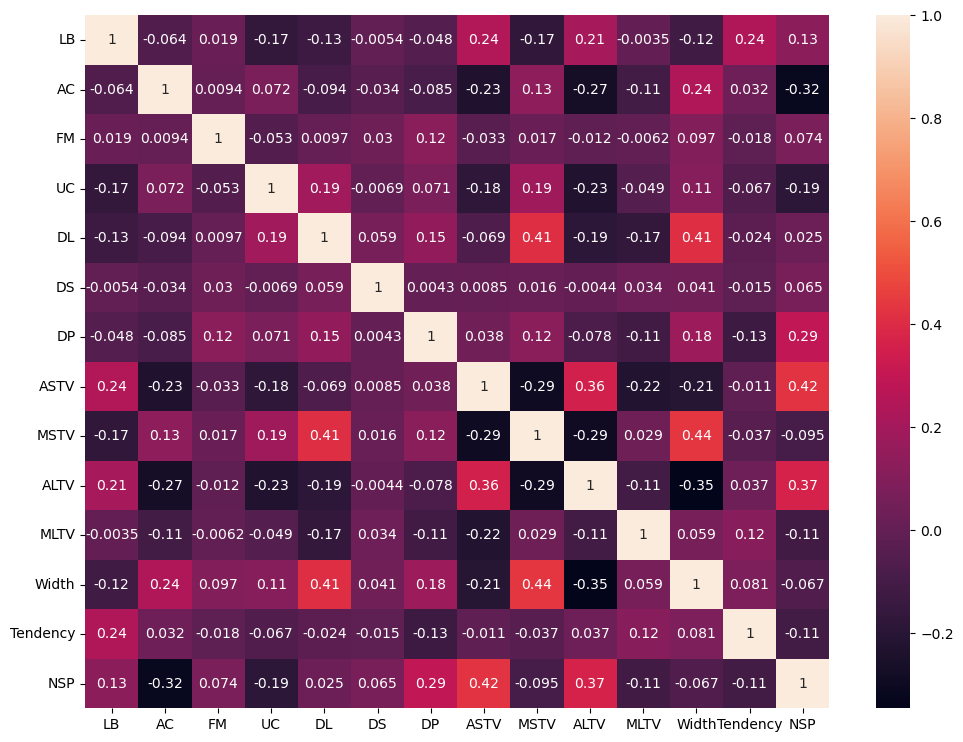

In [24]:
#there are no catgorical values to peform barchat or piechart

#correlation heatmap

plt.figure(figsize=(12,9))
sns.heatmap(data.corr(numeric_only=True),annot=True)
plt.show()

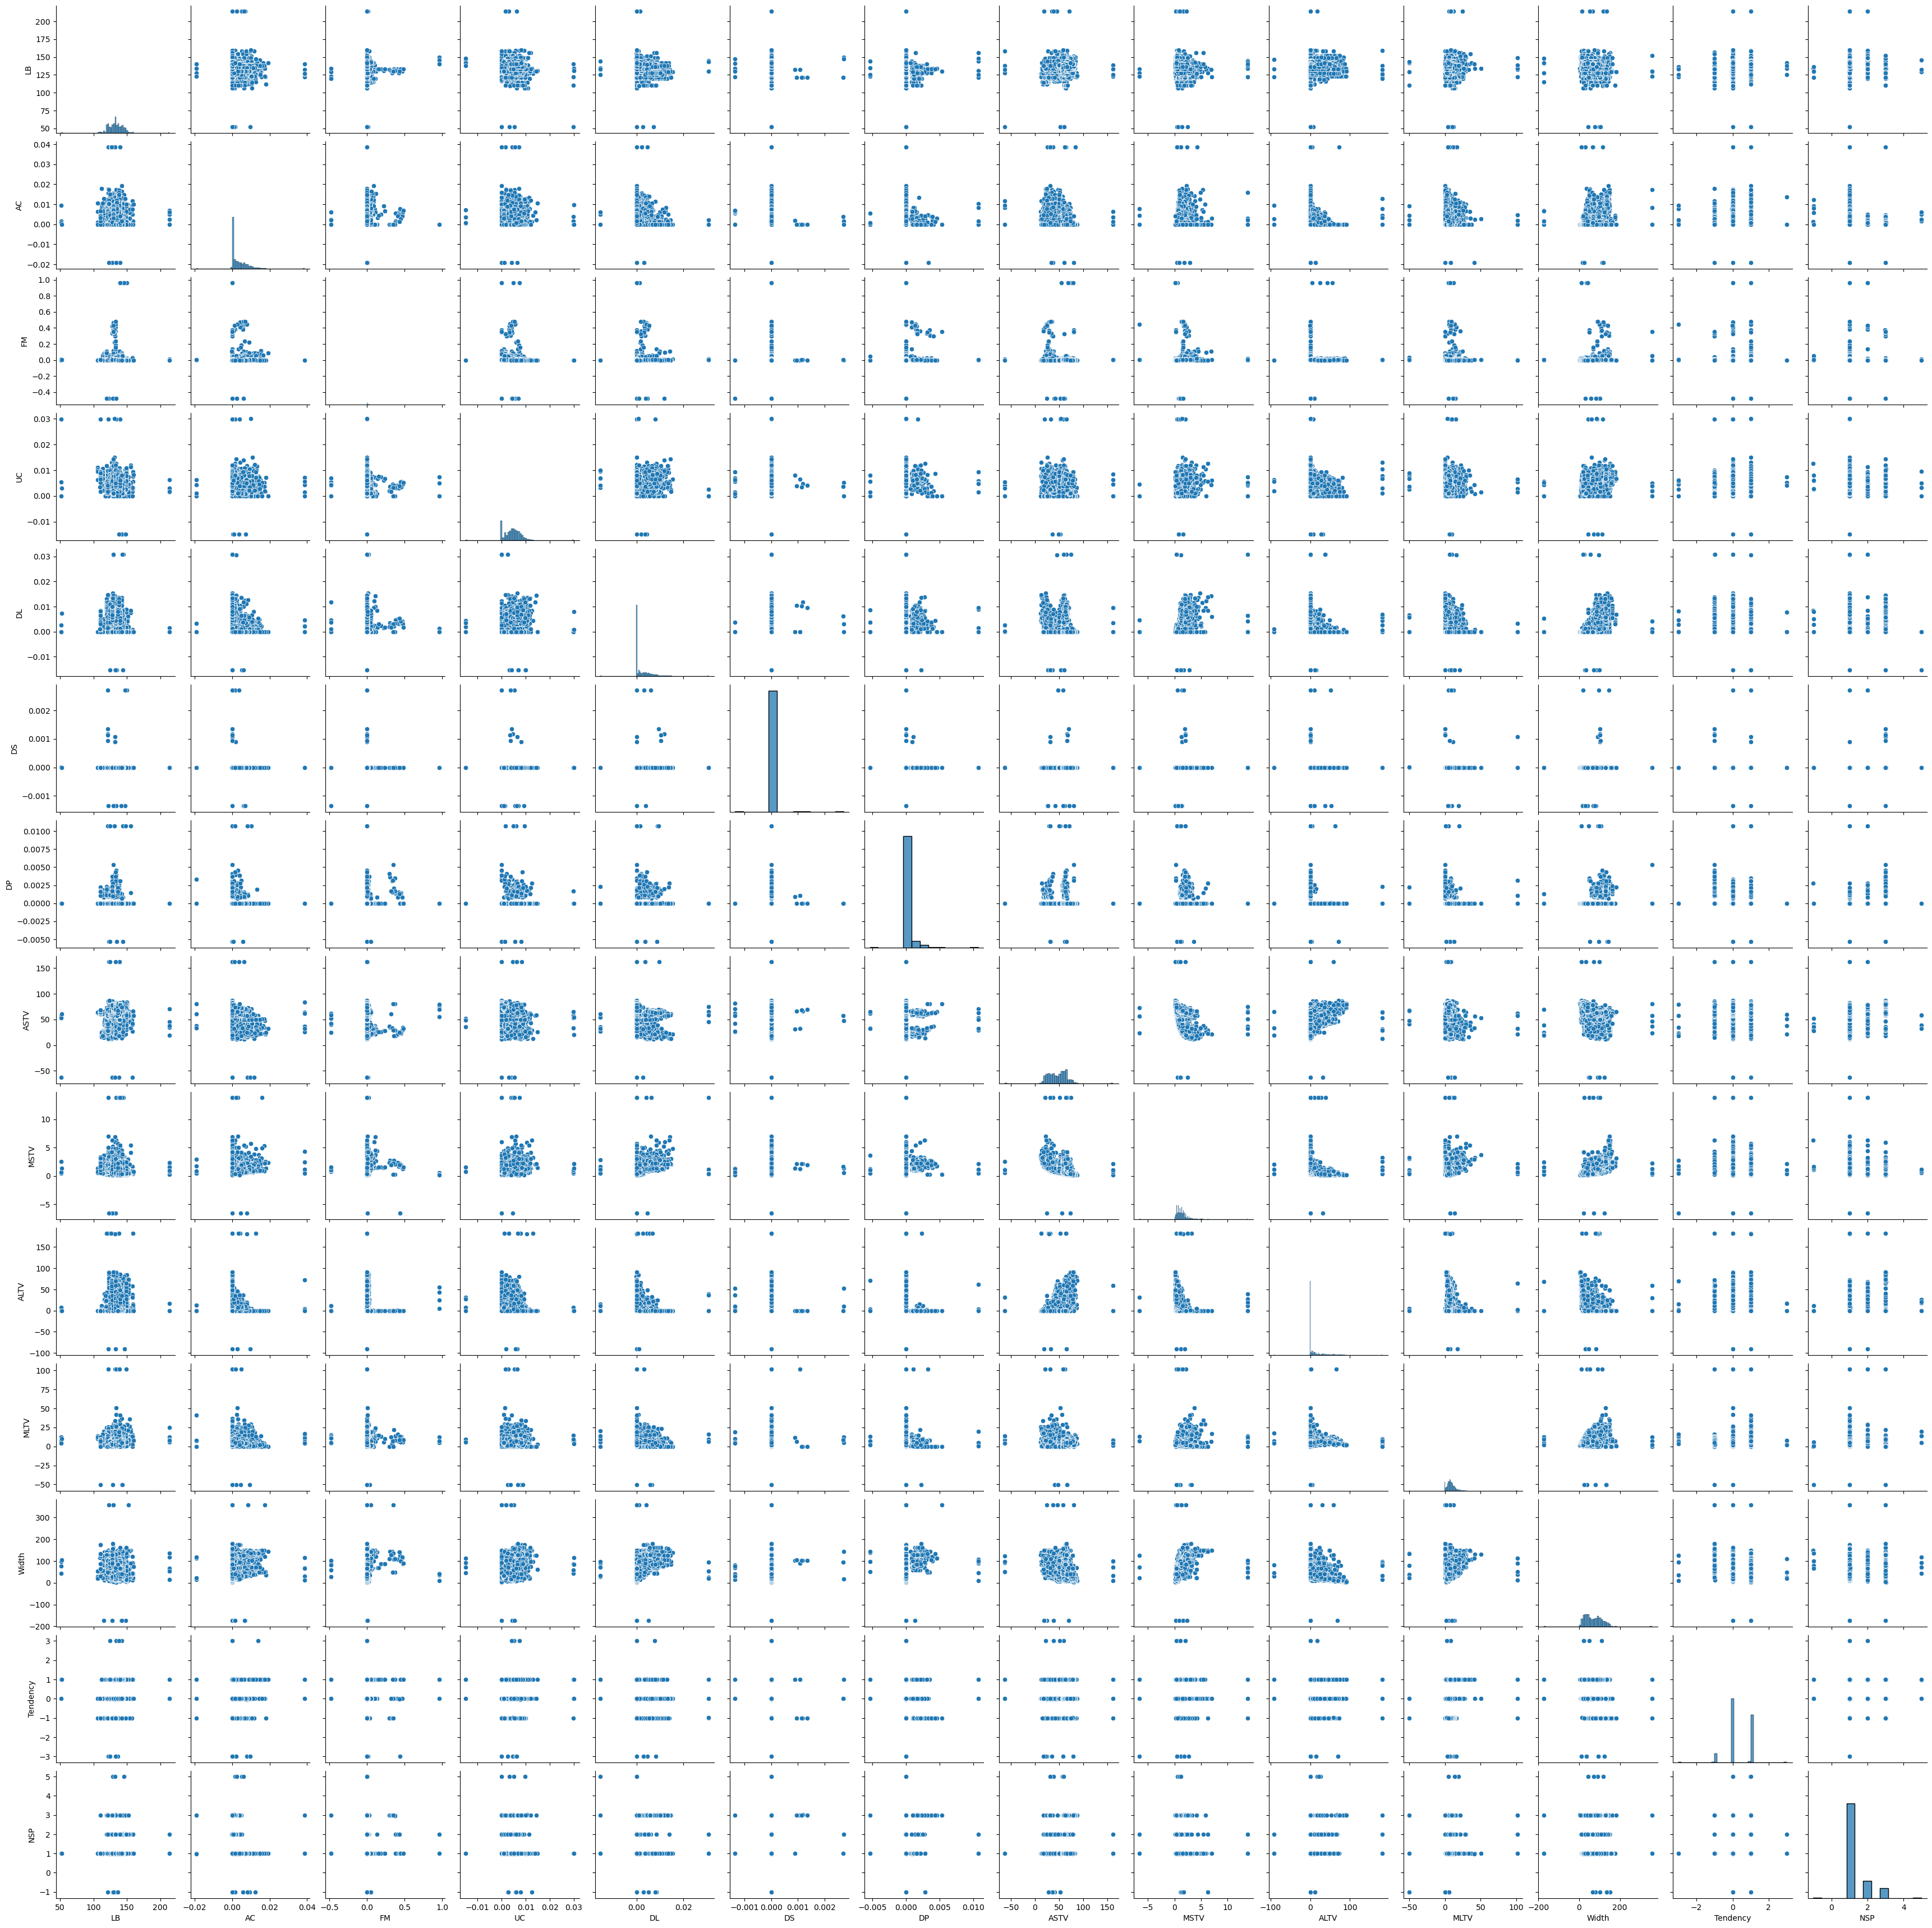

In [25]:
#pairplot
sns.pairplot(data)
plt.show()

### Conclusion
#### - missing values and outliers were handled to ensure clean, consistent data.

#### - variablity measures (ASTV,MSTV,ALTV,MLTV) and decleration patterns (DL,DS,DP) were key indicators of fetal health

#### - strong correlations were observed among (ASTV,ALTV,MLTV).

#### - the target variable (NSP) showed class imbalance.

#### - EDA cleaned and structured the dataset, reveable key physiological patterns, and identified predictors of fetal well-being to support predictive modeling and better fetal monitoring